# Demo: Evaluation on ClinicalNotes v0

Access data here: https://huggingface.co/datasets/jmaasch/compositional_causal_reasoning

This demo provides a walk-through of:
1. How to use the ClinicalNotes datasets for CCR evaluation.
   - Standard metrics: F1, accuracy, precision, recall.
   - Metrics for counterfactual reasoning evaluation: external validity RAE and internal consistency RAE.
2. How to generate new random ClinicalNotes tasks.

For more information on the counterfactual reasoning metrics, see [Maasch et al. 2025 (ICML)](https://arxiv.org/abs/2503.04556).

Code by Jacqueline Maasch | April 2025

In [1]:
# General importations.
import pandas as pd
import numpy as np
import os
import sys
from ast import literal_eval
from sklearn.metrics import f1_score,precision_score,recall_score,accuracy_score

sys.path.insert(1, os.path.join(sys.path[0], '..'))
from utils import Utils
from clinical_notes import ClinicalNotes

In [2]:
u = Utils()

In [3]:
path = "../static_datasets/clinical_notes_v0/"

## Import static datasets

In [4]:
# Load raw data.
df = pd.read_csv(path+"clinical_notes_v0.csv")
print(df.info())
display(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 19 columns):
 #   Column                                  Non-Null Count  Dtype 
---  ------                                  --------------  ----- 
 0   Task ID                                 50000 non-null  object
 1   Context ID                              50000 non-null  int64 
 2   Sample ID                               50000 non-null  int64 
 3   Nodes per BCC                           50000 non-null  object
 4   Replicate ID                            50000 non-null  int64 
 5   DAG adjacency matrix                    50000 non-null  object
 6   DAG nodes                               50000 non-null  object
 7   CCT adjacency matrix                    50000 non-null  object
 8   CCT nodes                               50000 non-null  object
 9   Exogenous variables                     50000 non-null  object
 10  Bernoulli parameters                    50000 non-null  object
 11  Gl

,Task ID,Context ID,Sample ID,Nodes per BCC,Replicate ID,DAG adjacency matrix,DAG nodes,CCT adjacency matrix,CCT nodes,Exogenous variables,Bernoulli parameters,Global quantity,Local quantities,Compositions,Causal context,Sample context,Factual queries,Interventional queries (cause = True),Interventional queries (cause = False)
0,0.0.0,0,0,"[3, 3, 3]",0,[[0 1 1 0 0 0 0]\n [0 0 1 0 0 0 0]\n [0 0 0 1 ...,"['pain', 'RJS8', 'TTW1', 'OT3C', 'OVYI', 'PF2V...",[[0 1 1 1]\n [0 0 1 1]\n [0 0 0 1]\n [0 0 0 0]],"['pain', 'TTW1', 'OVYI', 'surgery']","['GT81', 'KG95', 'MELA', 'M348', '4Y2Y', 'DLY7...","[0.4, 0.6, 0.4, 0.7, 0.6, 0.7, 0.8]","('pain', 'surgery')","[('pain', 'TTW1'), ('pain', 'OVYI'), ('TTW1', ...","[[('pain', 'TTW1'), ('TTW1', 'OVYI'), ('OVYI',...",Chronic disease N9KAOX sometimes requires surg...,"Now, we will review the history and physical n...",{'surgery': {'Prompt': 'Given these history an...,"{('pain', 'surgery'): {'Prompt': 'Now suppose ...","{('pain', 'surgery'): {'Prompt': 'Now suppose ..."
1,0.0.1,0,0,"[3, 3, 3]",1,[[0 1 1 0 0 0 0]\n [0 0 1 0 0 0 0]\n [0 0 0 1 ...,"['pain', 'RJS8', 'TTW1', 'OT3C', 'OVYI', 'PF2V...",[[0 1 1 1]\n [0 0 1 1]\n [0 0 0 1]\n [0 0 0 0]],"['pain', 'TTW1', 'OVYI', 'surgery']","['GT81', 'KG95', 'MELA', 'M348', '4Y2Y', 'DLY7...","[0.4, 0.6, 0.4, 0.7, 0.6, 0.7, 0.8]","('pain', 'surgery')","[('pain', 'TTW1'), ('pain', 'OVYI'), ('TTW1', ...","[[('pain', 'TTW1'), ('TTW1', 'OVYI'), ('OVYI',...",Chronic disease N9KAOX sometimes requires surg...,"Now, we will review the history and physical n...",{'surgery': {'Prompt': 'Given these history an...,"{('pain', 'surgery'): {'Prompt': 'Now suppose ...","{('pain', 'surgery'): {'Prompt': 'Now suppose ..."
2,0.0.2,0,0,"[3, 3, 3]",2,[[0 1 1 0 0 0 0]\n [0 0 1 0 0 0 0]\n [0 0 0 1 ...,"['pain', 'RJS8', 'TTW1', 'OT3C', 'OVYI', 'PF2V...",[[0 1 1 1]\n [0 0 1 1]\n [0 0 0 1]\n [0 0 0 0]],"['pain', 'TTW1', 'OVYI', 'surgery']","['GT81', 'KG95', 'MELA', 'M348', '4Y2Y', 'DLY7...","[0.4, 0.6, 0.4, 0.7, 0.6, 0.7, 0.8]","('pain', 'surgery')","[('pain', 'TTW1'), ('pain', 'OVYI'), ('TTW1', ...","[[('pain', 'TTW1'), ('TTW1', 'OVYI'), ('OVYI',...",Chronic disease N9KAOX sometimes requires surg...,"Now, we will review the history and physical n...",{'surgery': {'Prompt': 'Given these history an...,"{('pain', 'surgery'): {'Prompt': 'Now suppose ...","{('pain', 'surgery'): {'Prompt': 'Now suppose ..."
3,0.0.3,0,0,"[3, 3, 3]",3,[[0 1 1 0 0 0 0]\n [0 0 1 0 0 0 0]\n [0 0 0 1 ...,"['pain', 'RJS8', 'TTW1', 'OT3C', 'OVYI', 'PF2V...",[[0 1 1 1]\n [0 0 1 1]\n [0 0 0 1]\n [0 0 0 0]],"['pain', 'TTW1', 'OVYI', 'surgery']","['GT81', 'KG95', 'MELA', 'M348', '4Y2Y', 'DLY7...","[0.4, 0.6, 0.4, 0.7, 0.6, 0.7, 0.8]","('pain', 'surgery')","[('pain', 'TTW1'), ('pain', 'OVYI'), ('TTW1', ...","[[('pain', 'TTW1'), ('TTW1', 'OVYI'), ('OVYI',...",Chronic disease N9KAOX sometimes requires surg...,"Now, we will review the history and physical n...",{'surgery': {'Prompt': 'Given these history an...,"{('pain', 'surgery'): {'Prompt': 'Now suppose ...","{('pain', 'surgery'): {'Prompt': 'Now suppose ..."
4,0.0.4,0,0,"[3, 3, 3]",4,[[0 1 1 0 0 0 0]\n [0 0 1 0 0 0 0]\n [0 0 0 1 ...,"['pain', 'RJS8', 'TTW1', 'OT3C', 'OVYI', 'PF2V...",[[0 1 1 1]\n [0 0 1 1]\n [0 0 0 1]\n [0 0 0 0]],"['pain', 'TTW1', 'OVYI', 'surgery']","['GT81', 'KG95', 'MELA', 'M348', '4Y2Y', 'DLY7...","[0.4, 0.6, 0.4, 0.7, 0.6, 0.7, 0.8]","('pain', 'surgery')","[('pain', 'TTW1'), ('pain', 'OVYI'), ('TTW1', ...","[[('pain', 'TTW1'), ('TTW1', 'OVYI'), ('OVYI',...",Chronic disease N9KAOX sometimes requires surg...,"Now, we will review the history and physical n...",{'surgery': {'Prompt': 'Given these history an...,"{('pain', 'surgery'): {'Prompt': 'Now suppose ...","{('pain', 'surgery'): {'Prompt': 'Now suppose ..."


In [5]:
# Convert adjacency matrices back to numpy arrays.
def string_to_array(array_string):
    cleaned_string = array_string.replace('\n', '')
    cleaned_string = cleaned_string.replace(' ', ', ')
    new_list = literal_eval(cleaned_string)
    return np.array(new_list)

print(string_to_array(df["DAG adjacency matrix"][0]))

df["DAG adjacency matrix"] = df["DAG adjacency matrix"].apply(string_to_array)

[[0 1 1 0 0 0 0]
 [0 0 1 0 0 0 0]
 [0 0 0 1 1 0 0]
 [0 0 0 0 1 0 0]
 [0 0 0 0 0 1 1]
 [0 0 0 0 0 0 1]
 [0 0 0 0 0 0 0]]


In [6]:
# Total observations per Context ID.
df["Context ID"].value_counts()

Context ID
0    25000
1    25000
Name: count, dtype: int64

In [7]:
# Total observations per graph size.
df["Nodes per BCC"].value_counts()

Nodes per BCC
[3, 3, 3]    25000
[4, 4, 4]    25000
Name: count, dtype: int64

In [8]:
# Load factual prompts.
df_f = pd.read_csv(path+"clinical_notes_factual_v0.csv")
print(df_f.info())
display(df_f.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   Task ID        150000 non-null  object
 1   Context ID     150000 non-null  int64 
 2   Sample ID      150000 non-null  int64 
 3   Replicate ID   150000 non-null  int64 
 4   Nodes per BCC  150000 non-null  object
 5   Effect         150000 non-null  object
 6   Context        150000 non-null  object
 7   Question       150000 non-null  object
 8   True           150000 non-null  int64 
dtypes: int64(4), object(5)
memory usage: 10.3+ MB
None


,Task ID,Context ID,Sample ID,Replicate ID,Nodes per BCC,Effect,Context,Question,True
0,0.0.0,0,0,0,"[3, 3, 3]",surgery,Chronic disease N9KAOX sometimes requires surg...,"Given these history and physical notes, will t...",1
1,0.0.0,0,0,0,"[3, 3, 3]",TTW1,Chronic disease N9KAOX sometimes requires surg...,"Given these history and physical notes, will l...",1
2,0.0.0,0,0,0,"[3, 3, 3]",OVYI,Chronic disease N9KAOX sometimes requires surg...,"Given these history and physical notes, will l...",1
3,0.0.1,0,0,1,"[3, 3, 3]",surgery,Chronic disease N9KAOX sometimes requires surg...,"Given these history and physical notes, will t...",1
4,0.0.1,0,0,1,"[3, 3, 3]",TTW1,Chronic disease N9KAOX sometimes requires surg...,"Given these history and physical notes, will l...",1


In [9]:
# Load counterfactual prompts.
df_cf = pd.read_csv(path+"clinical_notes_counterfactual_v0.csv")
print(df_cf.info())
display(df_cf.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 13 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   Task ID                   300000 non-null  object
 1   Context ID                300000 non-null  int64 
 2   Sample ID                 300000 non-null  int64 
 3   Replicate ID              300000 non-null  int64 
 4   Nodes per BCC             300000 non-null  object
 5   Cause-effect pair         300000 non-null  object
 6   Cause                     300000 non-null  object
 7   Effect                    300000 non-null  object
 8   Context                   300000 non-null  object
 9   Question (cause = True)   300000 non-null  object
 10  True (cause = True)       300000 non-null  int64 
 11  Question (cause = False)  300000 non-null  object
 12  True (cause = False)      300000 non-null  int64 
dtypes: int64(5), object(8)
memory usage: 29.8+ MB
None


,Task ID,Context ID,Sample ID,Replicate ID,Nodes per BCC,Cause-effect pair,Cause,Effect,Context,Question (cause = True),True (cause = True),Question (cause = False),True (cause = False)
0,0.0.0,0,0,0,"[3, 3, 3]","('pain', 'surgery')",pain,surgery,Chronic disease N9KAOX sometimes requires surg...,Now suppose that the patient will be in signif...,1,Now suppose that the patient will not be in pa...,1
1,0.0.0,0,0,0,"[3, 3, 3]","('pain', 'TTW1')",pain,TTW1,Chronic disease N9KAOX sometimes requires surg...,Now suppose that the patient will be in signif...,1,Now suppose that the patient will not be in pa...,1
2,0.0.0,0,0,0,"[3, 3, 3]","('pain', 'OVYI')",pain,OVYI,Chronic disease N9KAOX sometimes requires surg...,Now suppose that the patient will be in signif...,1,Now suppose that the patient will not be in pa...,1
3,0.0.0,0,0,0,"[3, 3, 3]","('TTW1', 'OVYI')",TTW1,OVYI,Chronic disease N9KAOX sometimes requires surg...,Now suppose that lab TTW1 will be elevated reg...,1,Now suppose that lab TTW1 will not be elevated...,1
4,0.0.0,0,0,0,"[3, 3, 3]","('TTW1', 'surgery')",TTW1,surgery,Chronic disease N9KAOX sometimes requires surg...,Now suppose that lab TTW1 will be elevated reg...,1,Now suppose that lab TTW1 will not be elevated...,1


In [10]:
# Load ground truth PNS values.
pns_dict = np.load(path+"clinical_notes_pns_dict_v0.npy",
                   allow_pickle = "TRUE").item()
display(pns_dict)

{0: {"('pain', 'surgery')": 0.0252,
  "('pain', 'TTW1')": 0.2332,
  "('pain', 'OVYI')": 0.0298,
  "('TTW1', 'OVYI')": 0.1236,
  "('TTW1', 'surgery')": 0.0982,
  "('OVYI', 'surgery')": 0.7946,
  "[('pain', 'TTW1'), ('TTW1', 'OVYI'), ('OVYI', 'surgery')]": 0.022903168991999998,
  "[('pain', 'TTW1'), ('TTW1', 'surgery')]": 0.02290024,
  "[('pain', 'OVYI'), ('OVYI', 'surgery')]": 0.023679079999999998},
 1: {"('pain', 'surgery')": 0.0038,
  "('pain', 'V4SB')": 0.0546,
  "('pain', 'UVXF')": 0.008,
  "('V4SB', 'UVXF')": 0.1494,
  "('V4SB', 'surgery')": 0.0684,
  "('UVXF', 'surgery')": 0.496,
  "[('pain', 'V4SB'), ('V4SB', 'UVXF'), ('UVXF', 'surgery')]": 0.00404599104,
  "[('pain', 'V4SB'), ('V4SB', 'surgery')]": 0.0037346400000000004,
  "[('pain', 'UVXF'), ('UVXF', 'surgery')]": 0.003968}}

In [11]:
# Load thresholds for internal consistency evaluation.
# By default, the multiplier was 1.0
# Here, we want a multiplier of 1.1, so we will update these values later.
threshold_dict = np.load(path+"clinical_notes_threshold_dict_v0.npy",
                         allow_pickle = "TRUE").item()
display(threshold_dict)

{0: {"[('pain', 'TTW1'), ('TTW1', 'OVYI'), ('OVYI', 'surgery')]": 0.09114408761904773,
  "[('pain', 'TTW1'), ('TTW1', 'surgery')]": 0.09126031746031751,
  "[('pain', 'OVYI'), ('OVYI', 'surgery')]": 0.06035396825396833},
 1: {"[('pain', 'V4SB'), ('V4SB', 'UVXF'), ('UVXF', 'surgery')]": 0.06473448421052641,
  "[('pain', 'V4SB'), ('V4SB', 'surgery')]": 0.017199999999999882,
  "[('pain', 'UVXF'), ('UVXF', 'surgery')]": 0.04421052631578952}}

## Simulate evaluation and error analysis

Subsample a single Context ID. For illustration, we will focus on Context 0.

In [12]:
# Sample Context 0.
df_0 = df[df["Context ID"] == 0]
df_f_0 = df_f[df_f["Context ID"] == 0]
df_cf_0 = df_cf[df_cf["Context ID"] == 0]

print(len(df_0))
print(len(df_f_0))
print(len(df_cf_0))

25000
75000
150000


In [13]:
df_0.columns

Index(['Task ID', 'Context ID', 'Sample ID', 'Nodes per BCC', 'Replicate ID',
       'DAG adjacency matrix', 'DAG nodes', 'CCT adjacency matrix',
       'CCT nodes', 'Exogenous variables', 'Bernoulli parameters',
       'Global quantity', 'Local quantities', 'Compositions', 'Causal context',
       'Sample context', 'Factual queries',
       'Interventional queries (cause = True)',
       'Interventional queries (cause = False)'],
      dtype='object')

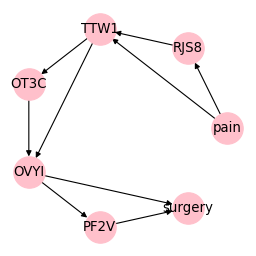

In [14]:
# View causal DAG (endogenous variables only).
u.plot_nx(df_0["DAG adjacency matrix"][0],
          labels = literal_eval(df_0["DAG nodes"][0]),
          figsize = (3,3), 
          dpi = 80)

### Associational level: Evaluate factual responses

In [15]:
# Perturb true responses to obtain synthetic predictions.
f_true = df_f_0["True"].to_numpy()
idx = np.random.choice(np.arange(len(f_true)), size = int(len(f_true)/100), replace = False)
f_pred = [f_true[i] if i not in idx else 1-f_true[i] for i in range(len(f_true))]
print(sum(np.where(f_pred != f_true, True, False)))

750


In [16]:
# Treat responses for all effects as one long vector.
# A finer-grained analysis would compute metrics separately for each effect.
print("F1        =", f1_score(f_true, f_pred))
print("Precision =", precision_score(f_true, f_pred))
print("Recall    =", recall_score(f_true, f_pred))
print("Accuracy  =", accuracy_score(f_true, f_pred))

F1        = 0.9942410467473431
Precision = 0.9985963721618953
Recall    = 0.9899235474006116
Accuracy  = 0.99


### Interventional level: Evaluate interventional responses

In [17]:
# Intervention (cause = True).
do_1_true = df_cf_0["True (cause = True)"].to_numpy()
idx = np.random.choice(np.arange(len(do_1_true)), size = int(len(do_1_true)/100), replace = False)
do_1_pred = [do_1_true[i] if i not in idx else 1-do_1_true[i] for i in range(len(do_1_true))]
print(sum(np.where(do_1_pred != do_1_true, True, False)))

1500


In [18]:
# Treat responses for all cause-effect pairs as one long vector.
# A finer-grained analysis would compute metrics separately for each cause-effect pair.
print("F1        =", f1_score(do_1_true, do_1_pred))
print("Precision =", precision_score(do_1_true, do_1_pred))
print("Recall    =", recall_score(do_1_true, do_1_pred))
print("Accuracy  =", accuracy_score(do_1_true, do_1_pred))

F1        = 0.9944031521447122
Precision = 0.9988082120932743
Recall    = 0.9900367769976597
Accuracy  = 0.99


In [19]:
# Intervention (cause = False).
do_0_true = df_cf_0["True (cause = False)"].to_numpy()
idx = np.random.choice(np.arange(len(do_0_true)), size = int(len(do_0_true)/100), replace = False)
do_0_pred = [do_0_true[i] if i not in idx else 1-do_0_true[i] for i in range(len(do_0_true))]
print(sum(np.where(do_0_pred != do_0_true, True, False)))

1500


In [20]:
# Treat responses for all cause-effect pairs as one long vector.
# A finer-grained analysis would compute metrics separately for each cause-effect pair.
print("F1        =", f1_score(do_0_true, do_0_pred))
print("Precision =", precision_score(do_0_true, do_0_pred))
print("Recall    =", recall_score(do_0_true, do_0_pred))
print("Accuracy  =", accuracy_score(do_0_true, do_0_pred))

F1        = 0.992628557949363
Precision = 0.9949363596957875
Recall    = 0.9903314375367719
Accuracy  = 0.99


### Counterfactual level: Evaluate PNS external validity and internal consistency

#### External validity of individual causal quantities

In [21]:
# Compute PNS estimates for each cause-effect pair.
# For illustration, we will demonstrate on (pain,surgery).
df_pred = pd.DataFrame({"Cause = True": do_1_pred, 
                        "Cause = False": do_0_pred})
pns_pred = u.get_pns_direct(df_pred,
                            y_do_x1 = "Cause = True", 
                            y_do_x0 = "Cause = False")
pns_true = pns_dict.get(0).get("('pain', 'surgery')")
external_validity_rae = u.get_rae(pns_true, pns_pred)

print("True PNS              =", pns_true)
print("Predicted PNS         =", pns_pred)
print("External validity RAE =", external_validity_rae)

True PNS              = 0.0252
Predicted PNS         = 0.22036666666666666
External validity RAE = 7.744708994708994


In [22]:
df_pred

,Cause = True,Cause = False
0,1,1
1,1,1
2,1,1
3,1,1
4,1,1
...,...,...
149995,1,1
149996,1,1
149997,1,1
149998,0,0


In [23]:
pns_dict.get(0)

{"('pain', 'surgery')": 0.0252,
 "('pain', 'TTW1')": 0.2332,
 "('pain', 'OVYI')": 0.0298,
 "('TTW1', 'OVYI')": 0.1236,
 "('TTW1', 'surgery')": 0.0982,
 "('OVYI', 'surgery')": 0.7946,
 "[('pain', 'TTW1'), ('TTW1', 'OVYI'), ('OVYI', 'surgery')]": 0.022903168991999998,
 "[('pain', 'TTW1'), ('TTW1', 'surgery')]": 0.02290024,
 "[('pain', 'OVYI'), ('OVYI', 'surgery')]": 0.023679079999999998}

#### Internal consistency and external validity of compositions

In [24]:
%%capture
# Compute PNS for composition.
# We will perturb the true values to simulate LM responses with errors.
df_pain_TTW1 = df_cf_0[df_cf_0["Cause-effect pair"] == "('pain', 'TTW1')"]
idx = np.random.choice(np.arange(len(df_pain_TTW1)), size = int(len(df_pain_TTW1)/100), replace = False)
true = df_pain_TTW1["True (cause = True)"].to_numpy()
df_pain_TTW1["Pred (cause = True)"] = [true[i] if i not in idx else 1-true[i] for i in range(len(true))]

idx = np.random.choice(np.arange(len(df_pain_TTW1)), size = int(len(df_pain_TTW1)/100), replace = False)
true = df_pain_TTW1["True (cause = False)"].to_numpy()
df_pain_TTW1["Pred (cause = False)"] = [true[i] if i not in idx else 1-true[i] for i in range(len(true))]

pns_pain_TTW1 = u.get_pns_direct(df_pain_TTW1,
                                 y_do_x1 = "Pred (cause = True)", 
                                 y_do_x0 = "Pred (cause = False)")

df_TTW1_surgery = df_cf_0[df_cf_0["Cause-effect pair"] == "('TTW1', 'surgery')"]
idx = np.random.choice(np.arange(len(df_pain_TTW1)), size = int(len(df_pain_TTW1)/100), replace = False)
true = df_TTW1_surgery["True (cause = True)"].to_numpy()
df_TTW1_surgery["Pred (cause = True)"] = [true[i] if i not in idx else 1-true[i] for i in range(len(true))]

true = df_TTW1_surgery["True (cause = False)"].to_numpy()
idx = np.random.choice(np.arange(len(df_pain_TTW1)), size = int(len(df_pain_TTW1)/100), replace = False)
df_TTW1_surgery["Pred (cause = False)"] = [true[i] if i not in idx else 1-true[i] for i in range(len(true))]

pns_TTW1_surgery = u.get_pns_direct(df_TTW1_surgery,
                                    y_do_x1 = "Pred (cause = True)", 
                                    y_do_x0 = "Pred (cause = False)")

In [25]:
# Compute RAE for external validity.
comp_true = pns_dict.get(0).get("[('pain', 'TTW1'), ('TTW1', 'surgery')]")
comp_pred = pns_pain_TTW1*pns_TTW1_surgery
external_validity_rae = u.get_rae(comp_true, comp_pred)
print("External validity RAE =", external_validity_rae)

# Compare to a threshold for validity.
thresh = 0.1
print("Desired RAE threshold =", thresh)
print("RAE <= threshold:", external_validity_rae <= thresh)

External validity RAE = 0.08814195833755456
Desired RAE threshold = 0.1
RAE <= threshold: True


In [26]:
# Compute RAE for internal consistency.
internal_consistency_rae = u.get_rae(pns_pred, comp_pred)
print("Internal consistency RAE =", internal_consistency_rae)

# Compare to pre-defined threshold.
# We will use a multiplier on the threshold to be generous.
thresh = threshold_dict.get(0).get("[('pain', 'TTW1'), ('TTW1', 'surgery')]")
thresh *= 1.25
print("Desired RAE threshold =", thresh)
print("RAE <= threshold:", internal_consistency_rae <= thresh)

Internal consistency RAE = 0.8869215912872485
Desired RAE threshold = 0.11407539682539689
RAE <= threshold: False


## Generate new tasks

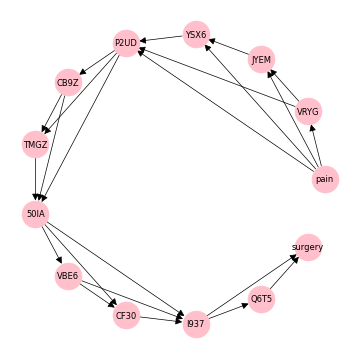


Causal context: Chronic disease 21PO3S sometimes requires surgical intervention, depending on genetics, patient history, vital signs, and lab results. The patient will experience significant pain (rated greater than or equal to 7/10) if they carry allele 2MF5, a genetic marker for severe 21PO3S. If the patient self-reports significant pain or the patient has a family history of 92AV, then lab VRYG will be elevated (greater than 2.78 mg/dL). If the patient self-reports significant pain or VRYG is elevated or the patient has previously received surgery for A3AL, then vital JYEM will be low (less than 1.84 mg/dL). If the patient self-reports significant pain or JYEM is low or the patient has a family history of 82Y0, then vital YSX6 will be elevated (greater than 2.6 mg/dL). If the patient self-reports significant pain or VRYG is elevated or YSX6 is elevated or the patient has a family history of Z1HE, then vital P2UD will be elevated (greater than 3.14 mg/dL). If P2UD is elevated or the

In [45]:
# Four BCCs of varying sizes and topology.
size = [5,4,4,3]
tg = ClinicalNotes(n_per_bcc = size, 
                   bcc_types = ["wheel", "wheel", "wheel", "cycle"])
context = tg.get_causal_context()
patient_history = tg.get_sample_context(n_extra_vars = 2)
print()
print("Causal context:", context)
print()
print("Patient history:", patient_history)
print()
print("- Global cause-effect pairs:", tg.get_global())
print("- Local cause-effect pairs:", tg.get_local())
print("- Compositions:", tg.get_compositions())

In [46]:
# See factual queries.
print()
print("- Factual queries:")
display(tg.get_factual_queries())


- Factual queries:


{'surgery': {'Prompt': 'Given these history and physical notes, will the surgeon recommend surgery? Begin your response with Yes or No and be as concise as possible.',
  'True endogenous': {'pain': 0,
   'VRYG': 0,
   'JYEM': 0,
   'YSX6': 1,
   'P2UD': 1,
   'CB9Z': 1,
   'TMGZ': 1,
   '50IA': 1,
   'VBE6': 1,
   'CF30': 1,
   'I937': 1,
   'Q6T5': 1,
   'surgery': 1},
  'True exogenous': {'2MF5': 0,
   '92AV': 0,
   'A3AL': 0,
   '82Y0': 1,
   'Z1HE': 0,
   'F7RJ': 1,
   'FX7G': 1,
   '0ZIM': 1,
   'JL3I': 0,
   'XAZK': 0,
   'T4KA': 0,
   'DULY': 1,
   'H7F4': 1},
  'True response': 1},
 'P2UD': {'Prompt': 'Given these history and physical notes, will vital P2UD be elevated? Begin your response with Yes or No and be as concise as possible.',
  'True endogenous': {'pain': 0,
   'VRYG': 0,
   'JYEM': 0,
   'YSX6': 1,
   'P2UD': 1,
   'CB9Z': 1,
   'TMGZ': 1,
   '50IA': 1,
   'VBE6': 1,
   'CF30': 1,
   'I937': 1,
   'Q6T5': 1,
   'surgery': 1},
  'True exogenous': {'2MF5': 0,
   '92AV

In [47]:
# See counterfactual query pairs (interventional = True and intervention = False).
cf_1, cf_0 = tg.get_counterfactual_queries()
print("- Interventional queries (cause = True):")
for key,val in cf_1.items():
    print("\n-----------------------")
    print("\n-- {} --".format(key))
    print("Prompt:", val.get("Prompt"))
    print("True endogenous:", val.get("True endogenous"))
    print("True exogenous:", val.get("True exogenous"))
    print("True response:", val.get("True response"))
print("\n-----------------------")

- Interventional queries (cause = True):

-----------------------

-- ('pain', 'surgery') --
Prompt: Now suppose that the patient will be in significant pain regardless of all other circumstances. With this new assumption, will the surgeon recommend surgery? Begin your response with Yes or No and be as concise as possible.
True endogenous: {'pain': 1, 'VRYG': 1, 'JYEM': 1, 'YSX6': 1, 'P2UD': 1, 'CB9Z': 1, 'TMGZ': 1, '50IA': 1, 'VBE6': 1, 'CF30': 1, 'I937': 1, 'Q6T5': 1, 'surgery': 1}
True exogenous: {'2MF5': 0, '92AV': 0, 'A3AL': 0, '82Y0': 1, 'Z1HE': 0, 'F7RJ': 1, 'FX7G': 1, '0ZIM': 1, 'JL3I': 0, 'XAZK': 0, 'T4KA': 0, 'DULY': 1, 'H7F4': 1}
True response: 1

-----------------------

-- ('pain', 'P2UD') --
Prompt: Now suppose that the patient will be in significant pain regardless of all other circumstances. With this new assumption, will vital P2UD be elevated? Begin your response with Yes or No and be as concise as possible.
True endogenous: {'pain': 1, 'VRYG': 1, 'JYEM': 1, 'YSX6': 1

In [48]:
print("- Interventional queries (cause = False):")
for key,val in cf_0.items():
    print("\n-----------------------")
    print("\n-- {} --".format(key))
    print("Prompt:", val.get("Prompt"))
    print("True endogenous:", val.get("True endogenous"))
    print("True exogenous:", val.get("True exogenous"))
    print("True response:", val.get("True response"))
print("\n-----------------------")

- Interventional queries (cause = False):

-----------------------

-- ('pain', 'surgery') --
Prompt: Now suppose that the patient will not be in pain regardless of all other circumstances. With this new assumption, will the surgeon recommend surgery? Begin your response with Yes or No and be as concise as possible.
True endogenous: {'pain': 0, 'VRYG': 0, 'JYEM': 0, 'YSX6': 1, 'P2UD': 1, 'CB9Z': 1, 'TMGZ': 1, '50IA': 1, 'VBE6': 1, 'CF30': 1, 'I937': 1, 'Q6T5': 1, 'surgery': 1}
True exogenous: {'2MF5': 0, '92AV': 0, 'A3AL': 0, '82Y0': 1, 'Z1HE': 0, 'F7RJ': 1, 'FX7G': 1, '0ZIM': 1, 'JL3I': 0, 'XAZK': 0, 'T4KA': 0, 'DULY': 1, 'H7F4': 1}
True response: 1

-----------------------

-- ('pain', 'P2UD') --
Prompt: Now suppose that the patient will not be in pain regardless of all other circumstances. With this new assumption, will vital P2UD be elevated? Begin your response with Yes or No and be as concise as possible.
True endogenous: {'pain': 0, 'VRYG': 0, 'JYEM': 0, 'YSX6': 1, 'P2UD': 1, 'C

In [49]:
# Sample observational data from the structural causal model (SCM).
df_obs, df_noise = tg.sample_scm(n = 5,
                                 intervene_node = None,
                                 intervene_value = 0)
display(df_obs.head())
display(df_noise.head())

,pain,VRYG,JYEM,YSX6,P2UD,CB9Z,TMGZ,50IA,VBE6,CF30,I937,Q6T5,surgery
0,0,1,1,1,1,1,1,1,1,1,1,1,1
1,1,1,1,1,1,1,1,1,1,1,1,1,1
2,0,0,1,1,1,1,1,1,1,1,1,1,0
3,0,1,1,1,1,1,1,1,1,1,1,1,0
4,0,1,1,1,1,1,1,1,1,1,1,1,0


,2MF5,92AV,A3AL,82Y0,Z1HE,F7RJ,FX7G,0ZIM,JL3I,XAZK,T4KA,DULY,H7F4
0,0,1,1,1,0,0,1,0,1,1,1,0,1
1,1,0,0,1,0,0,0,1,1,1,1,1,1
2,0,0,1,1,1,1,1,1,1,0,1,1,0
3,0,1,0,1,0,1,1,0,0,1,0,0,0
4,0,1,1,0,0,1,0,0,0,0,1,1,0


In [50]:
# Sample interventional data from the structural causal model (SCM).
causes = set([x[0] for x in [tg.get_global()]+tg.get_local()])
intervene_value = 1
for cause in causes:
    print("\n-- {} = {} --".format(cause,intervene_value))
    df_obs, df_noise = tg.sample_scm(n = 5,
                                     intervene_node = cause,
                                     intervene_value = intervene_value)
    display(df_obs.head())
    display(df_noise.head())


-- pain = 1 --


,pain,VRYG,JYEM,YSX6,P2UD,CB9Z,TMGZ,50IA,VBE6,CF30,I937,Q6T5,surgery
0,1,1,1,1,1,1,1,1,1,1,1,1,1
1,1,1,1,1,1,1,1,1,1,1,1,1,1
2,1,1,1,1,1,1,1,1,1,1,1,1,0
3,1,1,1,1,1,1,1,1,1,1,1,1,0
4,1,1,1,1,1,1,1,1,1,1,1,1,0


,2MF5,92AV,A3AL,82Y0,Z1HE,F7RJ,FX7G,0ZIM,JL3I,XAZK,T4KA,DULY,H7F4
0,0,1,1,1,0,0,1,0,1,1,1,0,1
1,1,0,0,1,0,0,0,1,1,1,1,1,1
2,0,0,1,1,1,1,1,1,1,0,1,1,0
3,0,1,0,1,0,1,1,0,0,1,0,0,0
4,0,1,1,0,0,1,0,0,0,0,1,1,0



-- 50IA = 1 --


,pain,VRYG,JYEM,YSX6,P2UD,CB9Z,TMGZ,50IA,VBE6,CF30,I937,Q6T5,surgery
0,0,1,1,1,1,1,1,1,1,1,1,1,1
1,1,1,1,1,1,1,1,1,1,1,1,1,1
2,0,0,1,1,1,1,1,1,1,1,1,1,0
3,0,1,1,1,1,1,1,1,1,1,1,1,0
4,0,1,1,1,1,1,1,1,1,1,1,1,0


...

,pain,VRYG,JYEM,YSX6,P2UD,CB9Z,TMGZ,50IA,VBE6,CF30,I937,Q6T5,surgery
0,0,1,1,1,1,1,1,1,1,1,1,1,1
1,1,1,1,1,1,1,1,1,1,1,1,1,1
2,0,0,1,1,1,1,1,1,1,1,1,1,0
3,0,1,1,1,1,1,1,1,1,1,1,1,0
4,0,1,1,1,1,1,1,1,1,1,1,1,0


,2MF5,92AV,A3AL,82Y0,Z1HE,F7RJ,FX7G,0ZIM,JL3I,XAZK,T4KA,DULY,H7F4
0,0,1,1,1,0,0,1,0,1,1,1,0,1
1,1,0,0,1,0,0,0,1,1,1,1,1,1
2,0,0,1,1,1,1,1,1,1,0,1,1,0
3,0,1,0,1,0,1,1,0,0,1,0,0,0
4,0,1,1,0,0,1,0,0,0,0,1,1,0



-- P2UD = 1 --


,pain,VRYG,JYEM,YSX6,P2UD,CB9Z,TMGZ,50IA,VBE6,CF30,I937,Q6T5,surgery
0,0,1,1,1,1,1,1,1,1,1,1,1,1
1,1,1,1,1,1,1,1,1,1,1,1,1,1
2,0,0,1,1,1,1,1,1,1,1,1,1,0
3,0,1,1,1,1,1,1,1,1,1,1,1,0
4,0,1,1,1,1,1,1,1,1,1,1,1,0


,2MF5,92AV,A3AL,82Y0,Z1HE,F7RJ,FX7G,0ZIM,JL3I,XAZK,T4KA,DULY,H7F4
0,0,1,1,1,0,0,1,0,1,1,1,0,1
1,1,0,0,1,0,0,0,1,1,1,1,1,1
2,0,0,1,1,1,1,1,1,1,0,1,1,0
3,0,1,0,1,0,1,1,0,0,1,0,0,0
4,0,1,1,0,0,1,0,0,0,0,1,1,0
